In [1]:
import rte
import vegas_params as vp
import numpy as np
import scipy
import gvar

In [2]:
import matplotlib.pyplot as plt

# Define the setup
## Light source
Isotropic laser, shining from the coordinates `(0,0,0)`

In [3]:
#define the light source
from laser import Laser

src = Laser(position=[0,0,0],
            time=0,
            # direction=vp.Direction(0., phi=-np.pi/2),
            direction=vp.Direction(1.,0),
            diffuser_sigma=1000,
            total_photons=1e15
           )

In [4]:
p = rte.Source(s=vp.Direction()).sample(1000)

In [5]:
lum = src.luminosity(p)/src.total_photons
#Laser.luminosity
lum = lum.flatten()
cosZ = p.s.z.flatten()
sinZ = np.sqrt(1-cosZ**2)

In [6]:
lum.mean()*(4*np.pi)

np.float64(1.0000266515874996)

In [7]:
(lum/sinZ).mean()

np.float64(0.12837306155707962)

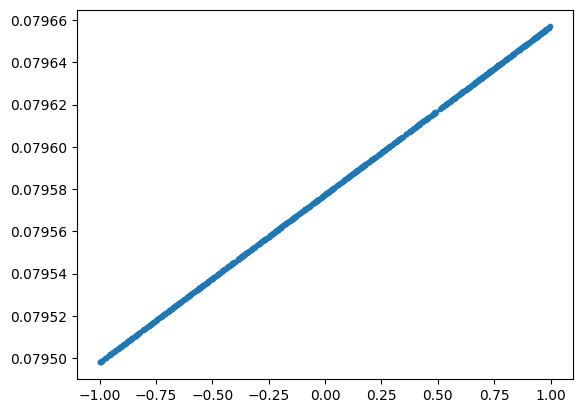

In [8]:
plt.plot(cosZ, lum, '.')

## Detectors
Spherical optical modules, distributed within a sperical volume 

In [216]:
#define the detector
from detector import BGVD_Module
tgt = BGVD_Module(
    center=vp.Vector([0,0,-1]), 
    T=0,
    # T = vp.Uniform([400e-9,5000e-9])#
)

Npoints = 200
positions = (vp.Direction()*vp.Uniform([1,10000])).sample(Npoints)
R = positions.mag().squeeze()
#sort by the distance for convenience
idx = np.argsort(R)
positions = positions[idx]
R = R[idx]

In [217]:
laser_wavelength = 532 #nm

#define the water medium
import medium
rte_water = medium.get_water_properties(laser_wavelength)
# rte_water.mu_a*=0
# rte_water.mu_s*=0
rte_water

Medium(mu_a=np.float64(0.0555), mu_s=np.float64(0.013999999999999999), c=np.float64(224247570.15699768), g=0.9)

# Expected theoretical calculation

$$
L_{exp} = N_{photons}\cdot \frac{\pi\; r_{OM}^2}{4\pi\;R^2} \cdot \exp\left[-\mu_t (R')\right]
$$

where $R'$ is an average distance to the module surface, taking into account attenuation, efficiency etc. 
For simple estimations we just know that $R<R'<R-r_{OM}$

In [245]:
#expected light
r_OM = tgt['radius'].sample()

L_exp = 1e15 * (np.pi*r_OM**2)/(4*np.pi * R**2)
L_exp = L_exp.squeeze()
L_exp0 = L_exp*rte_water.attenuation(R,n_scattering=0).squeeze()
L_exp1 = L_exp*rte_water.attenuation(R-r_OM,n_scattering=0).squeeze()
L_exp = np.mean([L_exp0,L_exp1], axis=0)

## The process object

In [246]:
from process import Process0
# c = rte.RTECalculator(src=src, tgt=tgt, medium = rte_water)
c = Process0(src=src, tgt=tgt, medium = rte_water)
c.vegas_kwargs = {'nitn':10, 'neval':1000}
# c.vegas_kwargs['adapt_params']={'nitn':10, 'neval':1000}
#run the calculation

# Calculate with a single "soft" factor

In [247]:
from time import perf_counter
from contextlib import contextmanager

In [248]:
@contextmanager
def measure_time():
    t1 = t2 = perf_counter()
    yield lambda: t2 - t1
    t2 = perf_counter()

In [249]:
results = {}

In [250]:
%%time
p = c#.get_process(0)
p.vegas_kwargs={'nitn':10, 'neval':10000}
p.vegas_kwargs['adapt_params']={'nitn':10, 'neval':10000}

with measure_time() as t:
    result = p.calculate_map(override={'tgt.center.xyz':positions}, output='reshape', max_workers=10)
    L = gvar.mean(result)

params = {**p.vegas_kwargs['adapt_params']}
results[(str(params),t())] = L

CPU times: user 277 ms, sys: 105 ms, total: 381 ms
Wall time: 1.35 s


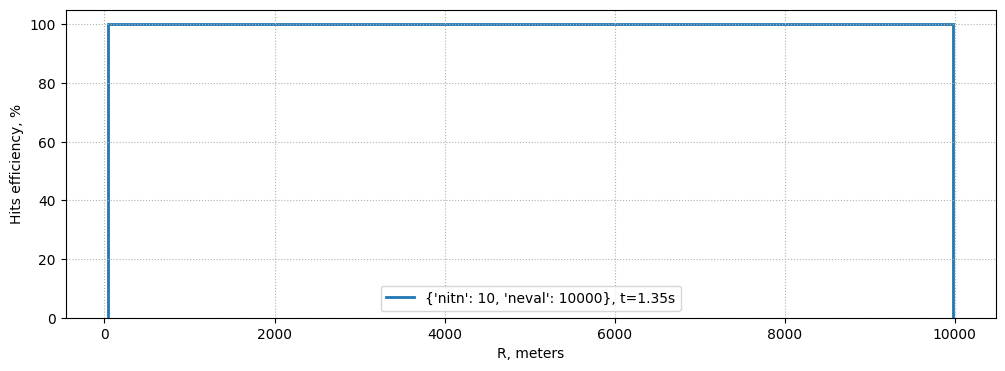

In [251]:
plt.figure(figsize=(12,4))
#efficiency of hits vs.distance:
bins = np.linspace(R.min(), R.max(),20)

for params,L in results.items():
    params,t = params
    N_tot,_ = np.histogram(R, bins)
    N_hit,_ = np.histogram(R, bins, weights=1.*(L>0))
    plt.stairs(N_hit/N_tot*100, bins, label=f'{params}, t={t:2.3g}s', lw=2)

plt.legend()
plt.ylabel('Hits efficiency, %')
plt.xlabel('R, meters')
plt.grid(ls=':')
plt.show()

In [252]:
print(f"{rte_water.c:g}")

2.24248e+08


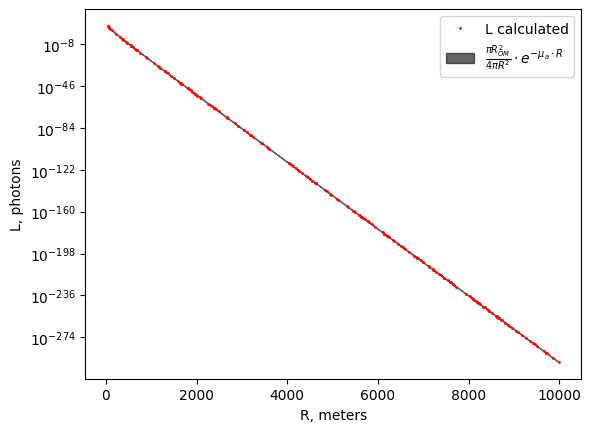

In [253]:
plt.plot(R, L, '.r', label='L calculated', markersize=2)
plt.fill_between(R, L_exp0, L_exp1, color='k', alpha=0.6,
                 label=r'$\frac{\pi R_{OM}^2}{4\pi R^2} \cdot e^{-\mu_a\cdot R}$')
plt.legend()
plt.yscale('log')
# plt.xscale('log')
plt.xlabel('R, meters')
plt.ylabel('L, photons')
plt.show()

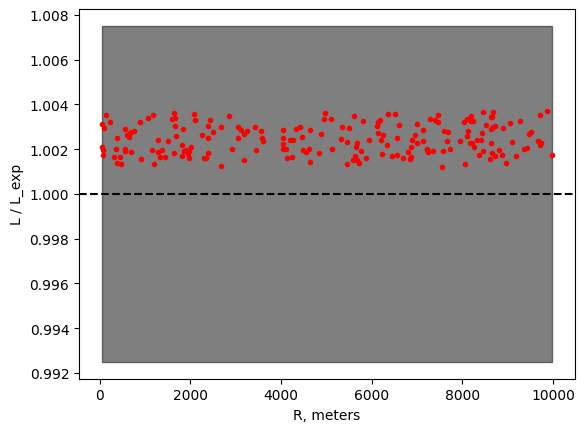

In [260]:
plt.plot(R, L/L_exp, '.r', label='L/L_exp')
# plt.yscale('log')
# plt.xscale('log')
plt.xlabel('R, meters')
plt.ylabel('L / L_exp')
plt.axhline(1,ls='--', color='black')
plt.fill_between(R, L_exp0/L_exp, L_exp1/L_exp, color='k', alpha=0.5)
# plt.legend()
plt.show()